# 0. Импорт библиотек

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from phik import resources, report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer


pd.set_option('display.max_rows', None)      # Показывать все строки
pd.set_option('display.max_columns', None)   # Показывать все столбцы
pd.set_option('display.width', None)         # Авто-ширина
pd.set_option('display.max_colwidth', None)  # Показывать полное содержимое ячеек

# 1. Извлечение данных (Extract)

Загрузка тренировочных данных по ссылке с Hugging Face Hub (csv файл) (валидационные и тестовые данные будут загружены отдельно)

In [3]:
df = pd.read_csv("../data/raw/raw_eda_telco_customer_churn_train.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4225 entries, 0 to 4224
Data columns (total 52 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                4225 non-null   int64  
 1   Avg Monthly GB Download            4225 non-null   int64  
 2   Avg Monthly Long Distance Charges  4225 non-null   float64
 3   Churn Category                     1121 non-null   object 
 4   Churn Reason                       1121 non-null   object 
 5   Churn Score                        4225 non-null   int64  
 6   City                               4225 non-null   object 
 7   CLTV                               4225 non-null   int64  
 8   Contract                           4225 non-null   object 
 9   Country                            4225 non-null   object 
 10  Customer ID                        4225 non-null   object 
 11  Customer Status                    4225 non-null   objec

In [5]:
df.head(5)

,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn Category,Churn Reason,Churn Score,City,CLTV,Contract,Country,Customer ID,Customer Status,Dependents,Device Protection Plan,Gender,Internet Service,Internet Type,Lat Long,Latitude,Longitude,Married,Monthly Charge,Multiple Lines,Number of Dependents,Number of Referrals,Offer,Online Backup,Online Security,Paperless Billing,Partner,Payment Method,Phone Service,Population,Premium Tech Support,Quarter,Referred a Friend,Satisfaction Score,Senior Citizen,State,Streaming Movies,Streaming Music,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data,Zip Code,Churn
0,72,4,19.44,NaN,NaN,51,San Mateo,4849,Two Year,United States,4526-ZJJTM,Stayed,0,1,Female,1,Fiber Optic,"37.538309, -122.305109",37.538309,-122.305109,1,88.40,0,0,1,NaN,1,0,0,1,Bank Withdrawal,1,37926,0,Q3,1,3,1,California,1,1,0,25,2191.15,0,486.00,0.0,2677.15,0,1,94403,0
1,27,59,45.62,NaN,NaN,27,Sutter Creek,3715,Month-to-Month,United States,5302-BDJNT,Stayed,0,1,Male,1,Fiber Optic,"38.432145, -120.77069",38.432145,-120.770690,0,95.50,1,0,0,NaN,0,0,0,0,Bank Withdrawal,1,4610,1,Q3,0,3,0,California,0,0,1,35,3418.20,0,1596.70,0.0,5014.90,1,1,95685,0
2,59,0,16.07,NaN,NaN,59,Santa Cruz,5092,Month-to-Month,United States,5468-BPMMO,Stayed,0,0,Male,0,NaN,"37.007882, -122.065975",37.007882,-122.065975,1,19.60,0,0,3,NaN,0,0,0,1,Bank Withdrawal,1,4563,0,Q3,1,5,0,California,0,0,0,46,851.20,0,739.22,0.0,1590.42,0,0,95064,0
3,25,27,0.00,NaN,NaN,49,Brea,2068,One Year,United States,2212-LYASK,Stayed,0,1,Male,1,DSL,"33.924143, -117.79387",33.924143,-117.793870,1,45.85,0,0,3,NaN,1,0,1,1,Credit Card,0,1408,0,Q3,1,4,0,California,1,1,0,27,1246.40,30,0.00,0.0,1276.40,1,0,92823,0
4,31,21,17.22,Dissatisfaction,Network reliability,88,San Jose,4026,One Year,United States,0378-XSZPU,Churned,0,1,Male,1,Cable,"37.311088, -121.961786",37.311088,-121.961786,1,60.30,0,0,1,Offer B,1,1,0,1,Credit Card,1,29914,0,Q3,1,2,0,California,0,0,0,58,3563.80,0,998.76,0.0,4562.56,0,1,95117,1


In [6]:
columns = df.columns
print(columns)

Index(['Age', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges',
       'Churn Category', 'Churn Reason', 'Churn Score', 'City', 'CLTV',
       'Contract', 'Country', 'Customer ID', 'Customer Status', 'Dependents',
       'Device Protection Plan', 'Gender', 'Internet Service', 'Internet Type',
       'Lat Long', 'Latitude', 'Longitude', 'Married', 'Monthly Charge',
       'Multiple Lines', 'Number of Dependents', 'Number of Referrals',
       'Offer', 'Online Backup', 'Online Security', 'Paperless Billing',
       'Partner', 'Payment Method', 'Phone Service', 'Population',
       'Premium Tech Support', 'Quarter', 'Referred a Friend',
       'Satisfaction Score', 'Senior Citizen', 'State', 'Streaming Movies',
       'Streaming Music', 'Streaming TV', 'Tenure in Months', 'Total Charges',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Refunds', 'Total Revenue', 'Under 30', 'Unlimited Data',
       'Zip Code', 'Churn'],
      dtype='object')


# 2. Описание признаков

| № | Наименование | Описание | Тип данных | Примечание | Использование в ML |
|---|-------------|-------------------|----------------|--------|-------------|
| 1 | Age | Возраст абонента в годах| int64 |  -  |  +  |
| 2 | Avg Monthly GB Download | Средний ежемесячный объем загрузок клиента в гигабайтах  | int64 | - | + |
| 3 | Avg Monthly Long Distance Charges | Средние ежемесячные расходы клиента на междугородние звонки | float64 | - | + |
| 4 | Churn Category | Общая категория, определяющая причину ухода клиента | object | Сильный предиктор, объясняет целевую переменную | - |
| 5 | Churn Reason | Причина ухода клиента | object | Сильный предиктор, объясняет целевую переменную | - |
| 6 | Churn Score | Оценка от 0 до 100, указывающая на вероятность ухода клиента | int64 | Сильный предиктор, объясняет целевую переменную | - |
| 7 | City | Город проживания абонента | object | Имеет слишком много значений, оставим только Штаты | - |
| 8 | CLTV | Customer Lifetime Value - пожизненная ценность клиента | int64 | Показывает, сколько чистой прибыли принесёт клиент за всё время | + |
| 9 | Contract | Тип договора | object | - | + |
| 10 | Country | Страна проживания клиента | object | - | + |
| 11 | Customer ID | Уникальный идентификатор клиента | object | - | - |
| 12 | Customer Status | Статус абонента | object | Cтатус абонента на конец квартала (отказался от услуг, остался или возобновил сотрудничество), объясняет целевую переменную | - |
| 13 | Dependents | Иждивенцы | int64 | Есть ли у абонента иждивенцы, оставим признак Number of Dependents | - | 
| 14 | Device Protection Plan | План защиты устройства | int64 | Есть ли у клиента план защиты устройства | + |
| 15 | Gender | Пол абонента | object | - | + |
| 16 | Internet Service | Подписка на интернет-сервисы | int64 | - | + |
| 17 | Internet Type | Тип интернет-провайдера | object | - | + |
| 18 | Lat Long | Ширина и долгота места жительства абонента | object | Не имеет контекста в рамках ML, требует агрегации | - |
| 19 | Latitude | Широта места жительства клиента | float64 | Не имеет контекста в рамках ML, требует агрегации | - |
| 20 | Longitude | Долгота места жительства клиента | float64 | Не имеет контекста в рамках ML, требует агрегации | - |
| 21 | Married | Состоит ли в браке | int64 | - | + |
| 22 | Monthly Charge | Ежемесячная плата | float64 | Общая ежемесячная плата клиента за все предоставляемые услуги | + |
| 23 | Multiple Lines | Наличие нескольких линий | int64 | - | + |
| 24 | Number of Dependents | Количество иждивенцев | int64 | - | + |
| 25 | Number of Referrals | Количество рекомендаций | int64 | Число рекомендаций, сделанных клиентом | + |
| 26 | Offer | Предложение | object | Последнее маркетинговое предложение, которое клиент принял | + |
| 27 | Online Backup | Онлайн-резервное копирование | int64 | Есть ли у клиента услуга онлайн-резервного копирования | + |
| 28 | Online Security | Онлайн-безопасность | int64 | Есть ли у клиента услуга онлайн-безопасности | + |
| 29 | Paperless Billing | Онлайн выставление счетов | int64 | - | + |
| 30 | Partner | Есть ли партнёр у клиента | int64 | Возможна будет корреляция с Married | + |
| 31 | Payment Method | Способ оплаты | object | - | + |
| 32 | Phone Service | Телефоные услуги | int64 | Пользуется ли абонент услугами теелфонии | + |
| 33 | Population | Население | int64 | Предполагаемая численность населения в почтовом индексе клиента | - |
| 34 | Premium Tech Support | Премиальная техническая поддержка | int64 | - | + |
| 35 | Quarter | Квартал | object | Финансовый квартал, по которому получены данные | + |
| 36 | Referred a Friend | Рекомендация другу | int64 | Указывает, порекомендовал ли клиент кого-либо из своих знакомых | + |
| 37 | Satisfaction Score | Показатель удовлетворенности | int64 | Оценка удовлетворенности клиента | + |
| 38 | Senior Citizen | Является ли абонент пожилым человеком | int64 | Может коррелиовать с возрастом | - |
| 39 | State | Штат, где проживает абонент | object | - | + |
| 40 | Streaming Movies | Просмотр фильмов онлайн | int64 | Наличие у клиента услуги потокового просмотра фильмов | + |
| 41 | Streaming Music | Потоковая передача музыки | int64 | Наличие у клиента сервиса потоковой передачи музыки | + |
| 42 | Streaming TV | Потоковое телевидение | int64 | Наличие у клиента услуги потокового телевидения | + |
| 43 | Tenure in Months | Какой срок абонент является клиентом компании | int64 | - | + |
| 44 | Total Charges | Общая сумма, уплаченная клиентом | float64 | - | + |
| 45 | Total Extra Data Charges | Общая сумма дополнительных затрат на передачу данных | int64 | - | + |
| 46 | Total Long Distance Charges | Общая сумма междугородних звонков | float64 | - | + |
| 47 | Total Refunds | Общая сумма возвратов | float64 | - | + |
| 48 | Total Revenue | Общий доход | float64 | Общий доход, полученный от клиента | + |
| 49 | Under 30 | Младше 30 | int64 | Указывает, если клиенту меньше 30 лет, может коррелиовать с возрастом | - |
| 50 | Unlimited Data | Безлимитный трафик | int64 | Предоставляется ли клиенту безлимитный трафик | + |
| 51 | Zip Code | Почтовый индекс | int64 | Не имеет контекста в рамках ML, требует агрегации | - |
| 52 | Churn | Результат оттока клиента | int64 | Целевая переменная | + |

# 3. Преобразование данных (Transform)

Удалим из датасета признаки, которые не будут участвовать при построении модели:

In [7]:
df = df.drop(columns=['Churn Category', 'Churn Reason', 'Churn Score', 'Customer ID', 'Customer Status', 'Dependents', 'Under 30', 'Senior Citizen', 'Lat Long', 'Latitude', 'Longitude', 'City', 'Population', 'Zip Code'])

In [8]:
df.shape

(4225, 38)

Посчитаем дубликаты и пропущенные значения:

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isna().sum()

Age                                     0
Avg Monthly GB Download                 0
Avg Monthly Long Distance Charges       0
CLTV                                    0
Contract                                0
Country                                 0
Device Protection Plan                  0
Gender                                  0
Internet Service                        0
Internet Type                         886
Married                                 0
Monthly Charge                          0
Multiple Lines                          0
Number of Dependents                    0
Number of Referrals                     0
Offer                                2324
Online Backup                           0
Online Security                         0
Paperless Billing                       0
Partner                                 0
Payment Method                          0
Phone Service                           0
Premium Tech Support                    0
Quarter                           

Тип интернета и принятое маркетинковое предложение могут быть пустыми значения, поэтому оставим как отдельную категорию.

In [11]:
df['Internet Type'].fillna('0', inplace=True)
df['Offer'].fillna('0', inplace=True)

/tmp/ipykernel_8076/3996322266.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Internet Type'].fillna('0', inplace=True)
/tmp/ipykernel_8076/3996322266.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

Удалим признаки, которые имеют только одно уникальное значение:

In [12]:
col_drop = df.columns[df.nunique().values == 1]
col_drop

Index(['Country', 'Quarter', 'State'], dtype='object')

In [13]:
df = df.drop(columns=col_drop)

In [14]:
df.shape

(4225, 35)

In [15]:
df.describe(include="all")

,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,CLTV,Contract,Device Protection Plan,Gender,Internet Service,Internet Type,Married,Monthly Charge,Multiple Lines,Number of Dependents,Number of Referrals,Offer,Online Backup,Online Security,Paperless Billing,Partner,Payment Method,Phone Service,Premium Tech Support,Referred a Friend,Satisfaction Score,Streaming Movies,Streaming Music,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Unlimited Data,Churn
count,4225.000000,4225.000000,4225.000000,4225.000000,4225,4225.000000,4225,4225.000000,4225,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225,4225.000000,4225.000000,4225.000000,4225.000000,4225,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000
unique,NaN,NaN,NaN,NaN,3,NaN,2,NaN,4,NaN,NaN,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,Month-to-Month,NaN,Male,NaN,Fiber Optic,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Bank Withdrawal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,2193,NaN,2124,NaN,1829,NaN,NaN,NaN,NaN,NaN,2324,NaN,NaN,NaN,NaN,2325,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,46.451124,20.740828,22.766963,4409.751243,NaN,0.346982,NaN,0.790296,NaN,0.483314,64.906462,0.416095,0.472663,1.996686,NaN,0.350533,0.292544,0.592426,0.483314,NaN,0.899408,0.296568,0.459882,3.242367,0.382959,0.349586,0.383669,32.681893,2306.078107,6.965680,754.719141,1.953846,3065.809082,0.677870,0.265325
std,16.731518,20.366105,15.429992,1170.599119,NaN,0.476066,NaN,0.407146,NaN,0.499781,29.926014,0.492968,0.962002,3.044569,NaN,0.477193,0.454985,0.491441,0.499781,NaN,0.300823,0.456798,0.498447,1.200716,0.486166,0.476896,0.486336,24.621041,2271.448881,25.250169,854.909725,7.814374,2884.817379,0.467348,0.441559
min,19.000000,0.000000,0.000000,2003.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,18.250000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,18.800000,0.000000,0.000000,0.000000,21.360000,0.000000,0.000000
25%,32.000000,4.000000,9.050000,3493.000000,NaN,0.000000,NaN,1.000000,NaN,0.000000,38.550000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,9.000000,401.500000,0.000000,67.680000,0.000000,592.750000,0.000000,0.000000
50%,46.000000,17.000000,22.570000,4531.000000,NaN,0.000000,NaN,1.000000,NaN,0.000000,70.200000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,1.000000,0.000000,NaN,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,30.000000,1424.600000,0.000000,396.640000,0.000000,2151.470000,1.000000,0.000000
75%,60.000000,27.000000,36.170000,5381.000000,NaN,1.000000,NaN,1.000000,NaN,1.000000,89.750000,1.000000,0.000000,3.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,56.000000,3846.750000,0.000000,1200.000000,0.000000,4845.750000,1.000000,1.000000


Выделим числовые и категориальную признаки:

In [16]:
numeric = ['Age', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'CLTV', 'Monthly Charge', 
           'Number of Referrals', 'Satisfaction Score', 'Tenure in Months', 'Total Charges',
           'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Refunds', 'Total Revenue', 'Number of Dependents']
print(f'Всего {len(numeric)} числовых признаков')

Всего 14 числовых признаков


In [17]:
categorial = ['Contract', 'Device Protection Plan', 'Gender', 'Internet Service', 'Internet Type', 'Married',
              'Multiple Lines', 'Offer', 'Online Backup', 'Online Security', 'Paperless Billing', 'Partner',
              'Payment Method', 'Phone Service', 'Premium Tech Support', 'Referred a Friend', 'Streaming Movies',
              'Streaming Music', 'Streaming TV', 'Unlimited Data']
print(f'Всего {len(categorial)} категориальных признаков')

Всего 20 категориальных признаков


In [18]:
y = df['Churn']
df = df.drop(columns=['Churn'])
print(f'Целевая прееменная - Churn')

Целевая прееменная - Churn


In [19]:
df.shape

(4225, 34)

### 3.1 Рассмотрим графики распределения числовых признаков:

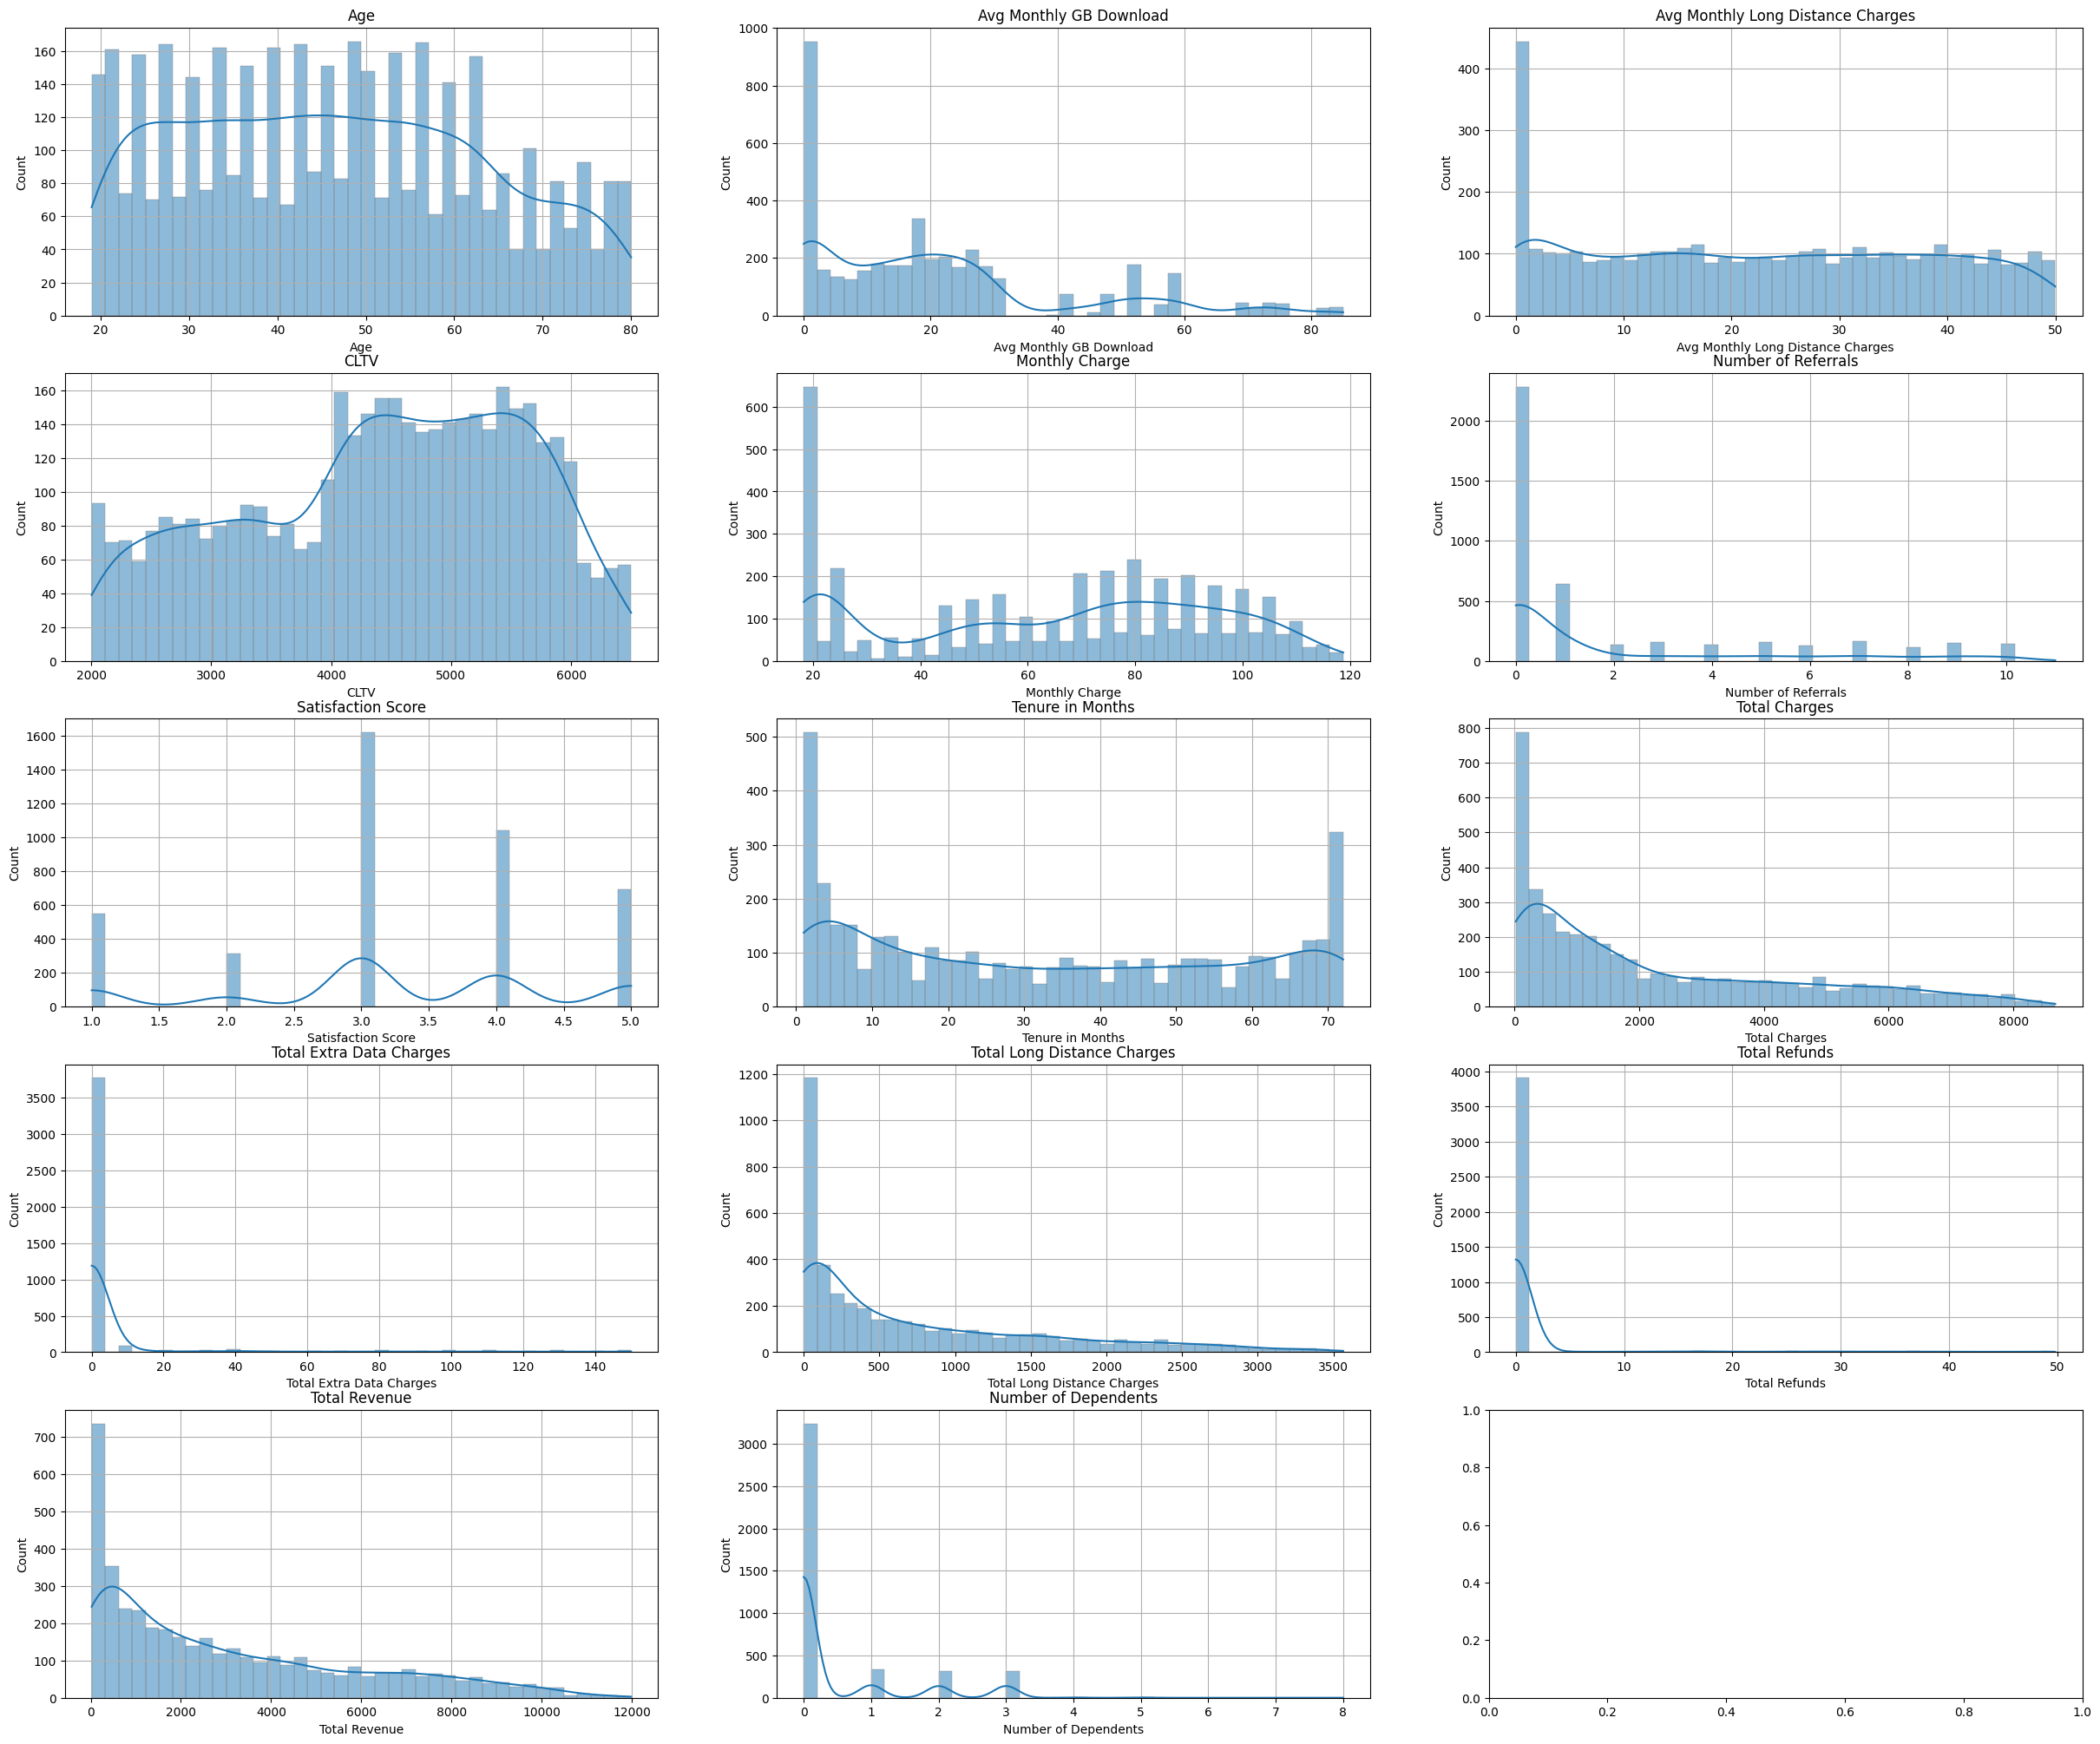

In [20]:
width = 3
height = (len(numeric) + width - 1)// width

fig, axes = plt.subplots(nrows=height, ncols=width, figsize=(width*10, height*5))
axes = axes.flatten()

for idx, column_name in enumerate(numeric):
    sns.histplot(data=df, x=column_name, bins=40,
                 kde=True, edgecolor='gray', linewidth=0.3, ax=axes[idx])
    axes[idx].set_title(column_name)
    axes[idx].grid()

Видимо, что есть очень много скошенных вправо признаков и признаков, где преобладает число значений равное нулю. Измерим скошенность и посчитаем число нулевых значений относительно всего датасета.

In [21]:
skewness = df[numeric].skew().sort_values(ascending=False)
print(skewness)

Total Refunds                        4.303082
Total Extra Data Charges             4.051127
Number of Dependents                 2.015498
Number of Referrals                  1.415296
Total Long Distance Charges          1.212608
Avg Monthly GB Download              1.196216
Total Charges                        0.938816
Total Revenue                        0.901802
Tenure in Months                     0.212766
Age                                  0.175097
Avg Monthly Long Distance Charges    0.057121
Monthly Charge                      -0.218466
CLTV                                -0.323119
Satisfaction Score                  -0.353287
dtype: float64


In [22]:
num_of_zero = (df[numeric] == 0).sum().sort_values(ascending=False) / df.shape[0]
print(num_of_zero)

Total Refunds                        0.924260
Total Extra Data Charges             0.893491
Number of Dependents                 0.766864
Number of Referrals                  0.540118
Avg Monthly GB Download              0.209704
Avg Monthly Long Distance Charges    0.100592
Total Long Distance Charges          0.100592
Monthly Charge                       0.000000
Age                                  0.000000
CLTV                                 0.000000
Total Charges                        0.000000
Tenure in Months                     0.000000
Satisfaction Score                   0.000000
Total Revenue                        0.000000
dtype: float64


4 признака (Total Refunds, Total Extra Data Charges, Number of Dependents, Number of Referrals) имеют сильную скошенность за счёт большого числа нулей. Переведём их в бинарные признаки, тогда признаки будут иметь следующие значения:

**Total Refunds** - Наличие возвратов

**Number of Dependents** - Наличие иждевенцев

**Total Extra Data Charges** - Наличие затрат на передачу данных

**Number of Referrals** - Наличие рекомендаций

In [23]:
df['Total Refunds'] = (df['Total Refunds']>0).astype(int)
df['Number of Dependents'] = (df['Number of Dependents']>0).astype(int)
df['Total Extra Data Charges'] = (df['Total Extra Data Charges']>0).astype(int)
df['Number of Referrals'] = (df['Number of Referrals']>0).astype(int)


In [24]:
exclude_cols = ['Total Refunds', 'Total Extra Data Charges', 'Number of Referrals', 'Number of Dependents']
numeric = [col for col in numeric if col not in exclude_cols]
categorial.extend(exclude_cols)

print(f'Всего {len(numeric)} числовых признаков')
print(f'Всего {len(categorial)} категориальных признака')

Всего 10 числовых признаков
Всего 24 категориальных признака


In [25]:
skewness = df[numeric].skew().sort_values(ascending=False)
print(skewness)

Total Long Distance Charges          1.212608
Avg Monthly GB Download              1.196216
Total Charges                        0.938816
Total Revenue                        0.901802
Tenure in Months                     0.212766
Age                                  0.175097
Avg Monthly Long Distance Charges    0.057121
Monthly Charge                      -0.218466
CLTV                                -0.323119
Satisfaction Score                  -0.353287
dtype: float64


Сохраним сильно скошенные признаки:

In [26]:
numeric_skew = df[numeric].skew()[df[numeric].skew() > 0.5].index.tolist()
print(numeric_skew)

['Avg Monthly GB Download', 'Total Charges', 'Total Long Distance Charges', 'Total Revenue']


### 3.2 Рассмотрим графики распределения категориальных признаков:

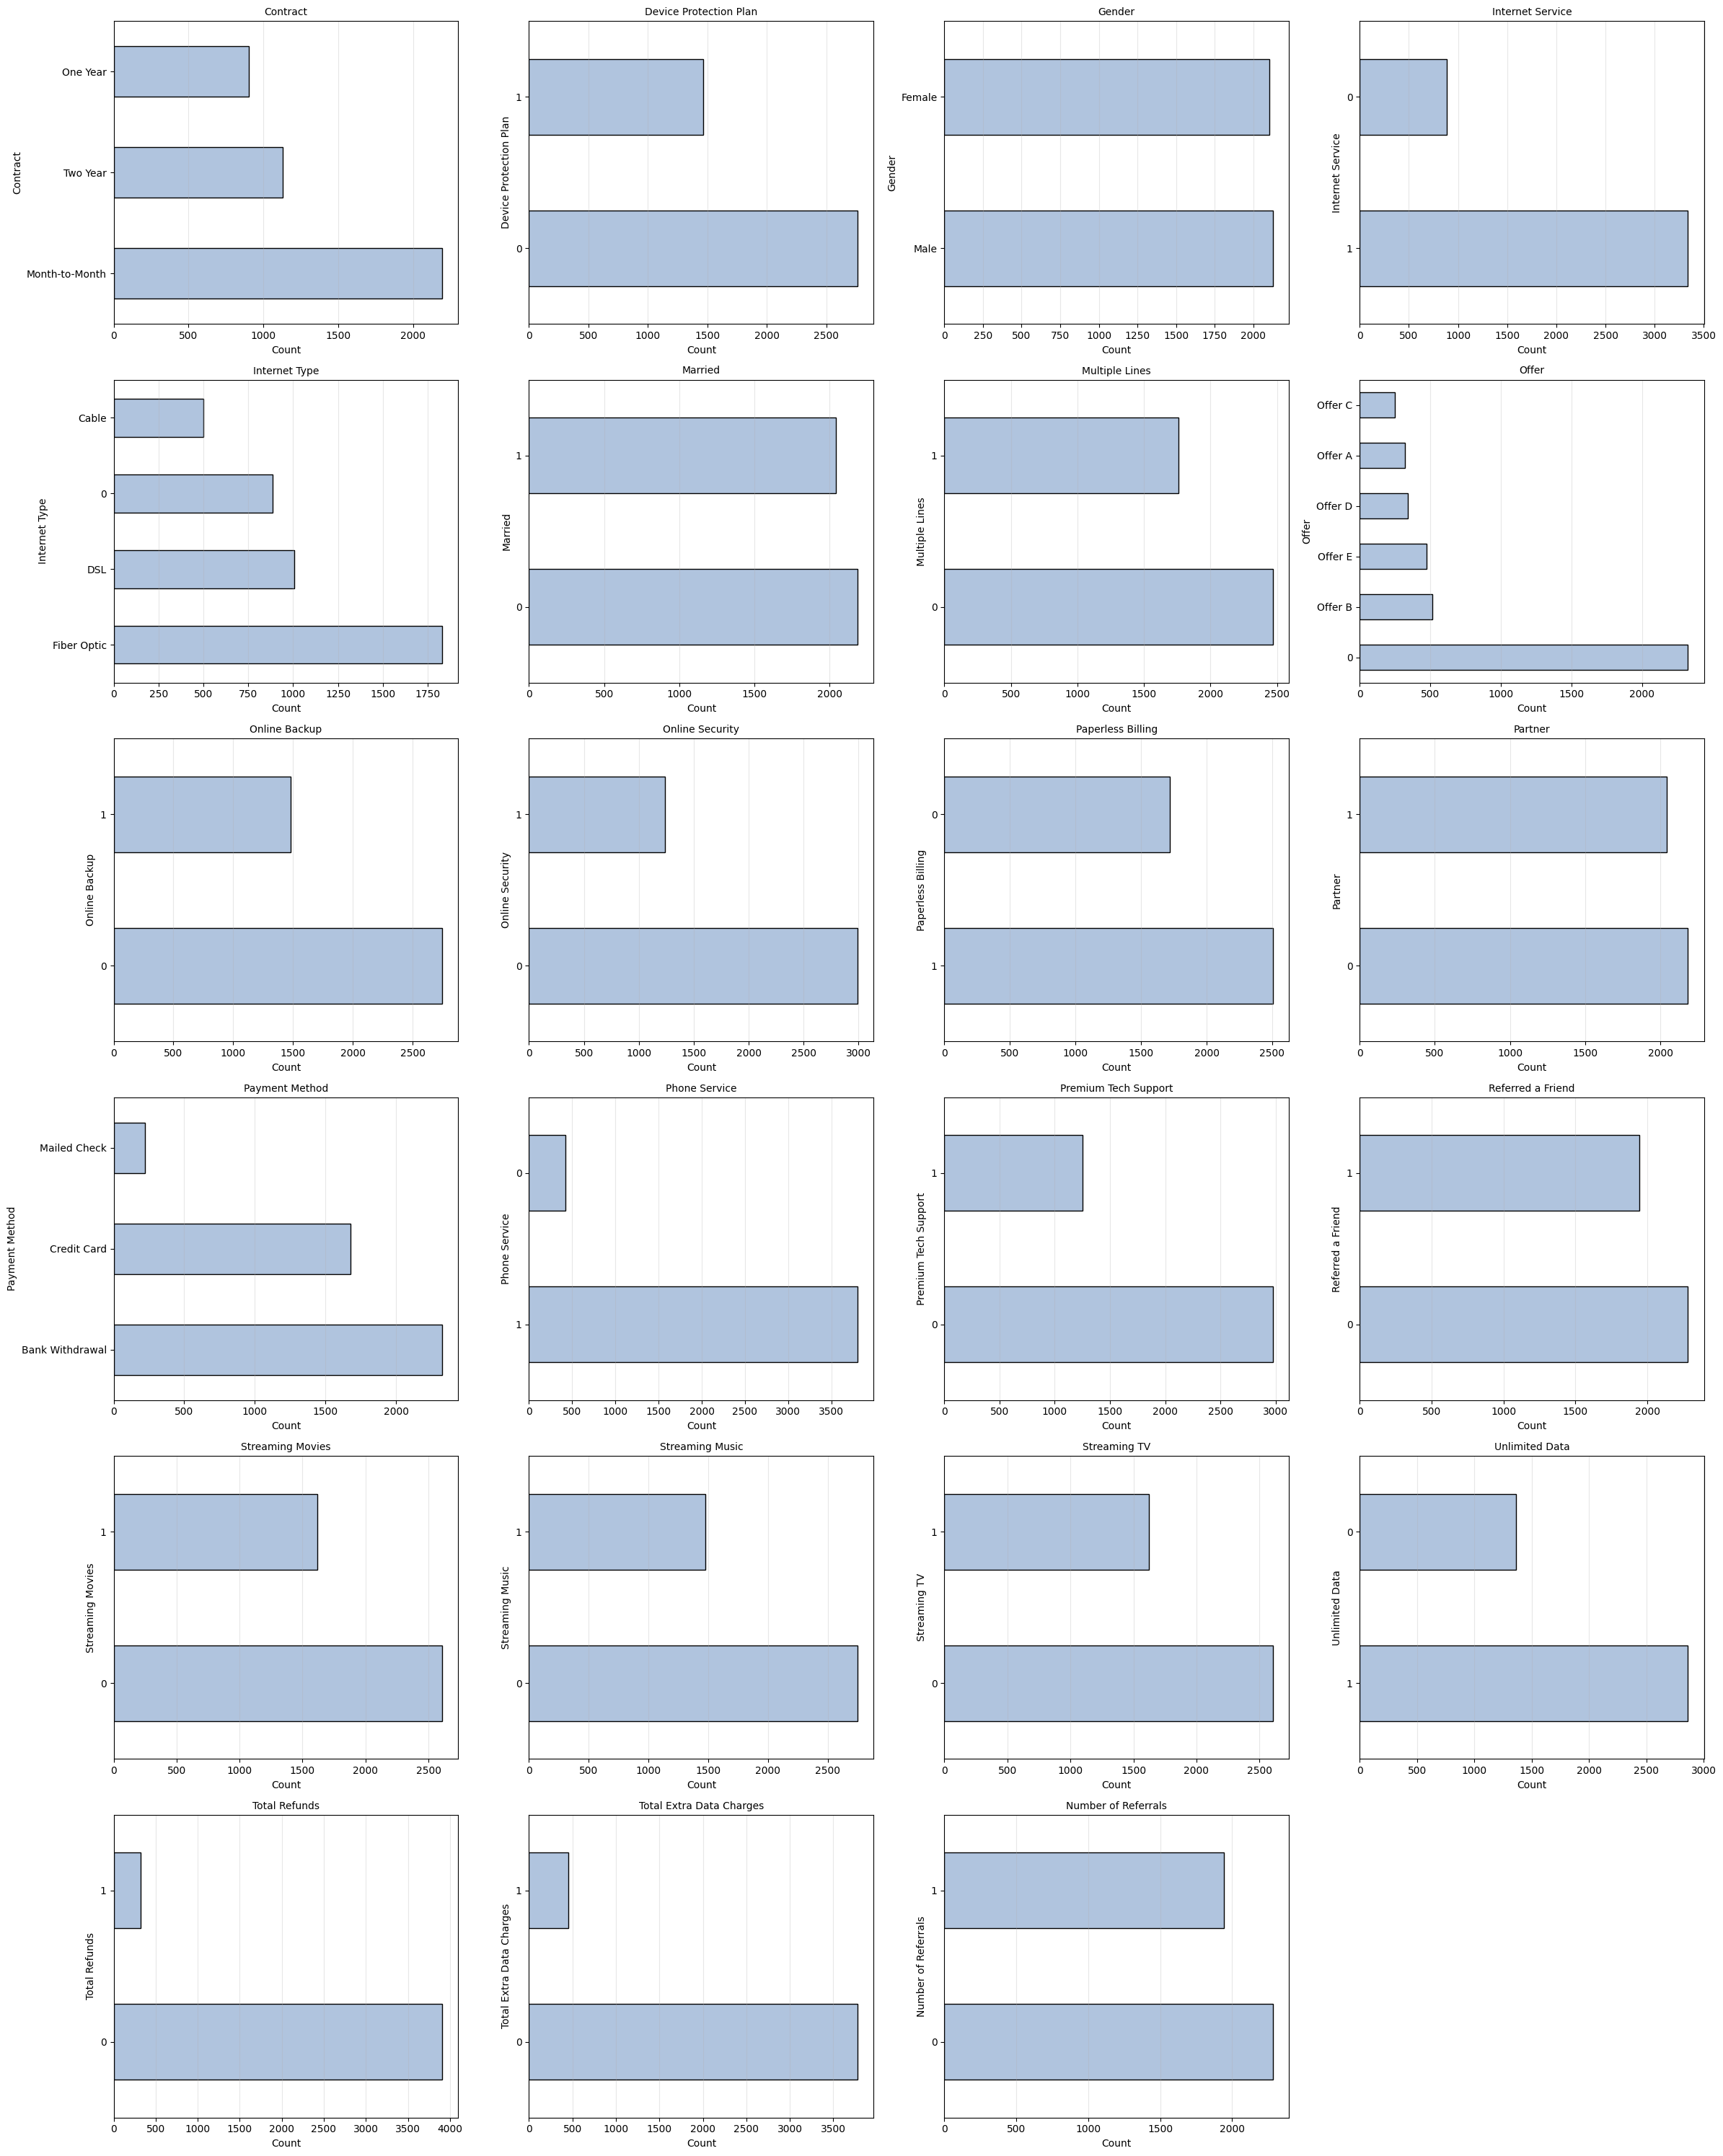

In [27]:
n_cols = 4  
n_rows = (len(categorial) + n_cols - 1) // n_cols  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(categorial):
    counts = df[col].value_counts()
    counts.plot(kind='barh', color='lightsteelblue', edgecolor='black', ax=axes[i])
    
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].set_xlabel('Count')
    axes[i].grid(axis='x', alpha=0.3)

for j in range(len(categorial)-1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

На графиках видно, что признак Offer имеет сильный дисбаланс, нулевые значения имеют составляют больше половины от всего объёма. Переведём этот признак в бинарный:

In [28]:
df['Offer'] = (df['Offer']!='0').astype(int)

In [29]:
df['Offer'].value_counts()

Offer
0    2324
1    1901
Name: count, dtype: int64

interval columns not set, guessing: ['Age', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'CLTV', 'Device Protection Plan', 'Internet Service', 'Married', 'Monthly Charge', 'Multiple Lines', 'Number of Dependents', 'Number of Referrals', 'Offer', 'Online Backup', 'Online Security', 'Paperless Billing', 'Partner', 'Phone Service', 'Premium Tech Support', 'Referred a Friend', 'Satisfaction Score', 'Streaming Movies', 'Streaming Music', 'Streaming TV', 'Tenure in Months', 'Total Charges', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Refunds', 'Total Revenue', 'Unlimited Data', 'Churn']


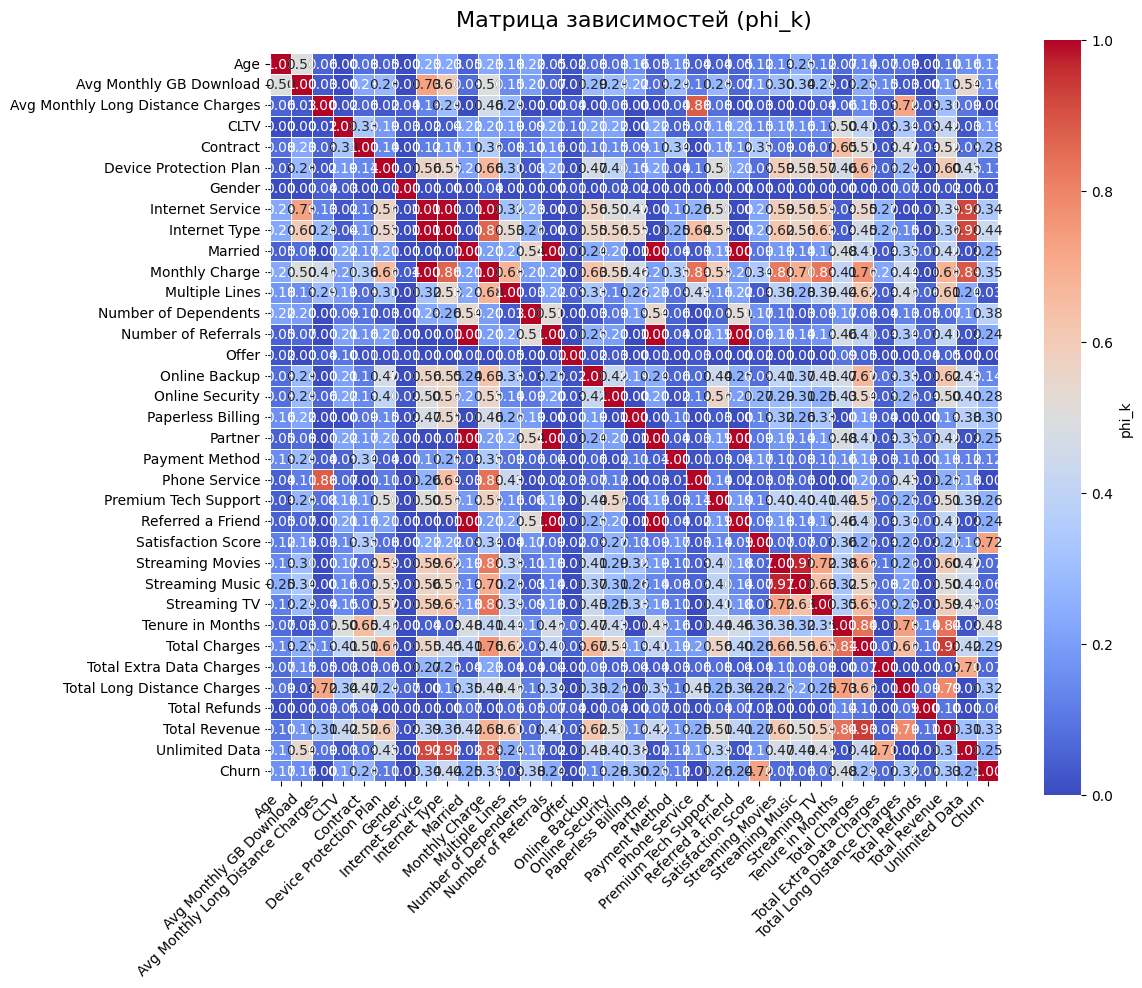

In [30]:
df_copy = df.copy()
df_copy['Churn'] = y
phik_matrix = df_copy.phik_matrix()

def plot_phik(phik_matrix):
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        phik_matrix,
        annot=True,         
        fmt=".2f",         
        cmap="coolwarm",    
        vmin=0,
        vmax=1,          
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "phi_k"}
    )

    plt.title("Матрица зависимостей (phi_k)", fontsize=16, pad=20)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_phik(phik_matrix)

In [31]:
threshold = 0.8
high_corr = phik_matrix[phik_matrix > threshold]
high_corr = high_corr[high_corr < 1]  # убираем диагональ

# Получаем список проблемных пар
correlated_pairs = []
for col in high_corr.columns:
    for idx in high_corr.index:
        if high_corr.loc[idx, col] > threshold and idx != col:
            correlated_pairs.append((idx, col, high_corr.loc[idx, col]))

print("Сильные корреляции:")
for pair in correlated_pairs:
    print(f"{pair[0]} <-> {pair[1]}: {pair[2]:.3f}")

Сильные корреляции:
Phone Service <-> Avg Monthly Long Distance Charges: 0.882
Monthly Charge <-> Internet Service: 0.999
Unlimited Data <-> Internet Service: 0.922
Monthly Charge <-> Internet Type: 0.864
Unlimited Data <-> Internet Type: 0.922
Number of Referrals <-> Married: 0.997
Referred a Friend <-> Married: 0.997
Internet Service <-> Monthly Charge: 0.999
Internet Type <-> Monthly Charge: 0.864
Phone Service <-> Monthly Charge: 0.839
Streaming Movies <-> Monthly Charge: 0.823
Streaming TV <-> Monthly Charge: 0.834
Unlimited Data <-> Monthly Charge: 0.887
Married <-> Number of Referrals: 0.997
Partner <-> Number of Referrals: 0.997
Number of Referrals <-> Partner: 0.997
Referred a Friend <-> Partner: 0.997
Avg Monthly Long Distance Charges <-> Phone Service: 0.882
Monthly Charge <-> Phone Service: 0.839
Married <-> Referred a Friend: 0.997
Partner <-> Referred a Friend: 0.997
Monthly Charge <-> Streaming Movies: 0.823
Streaming Music <-> Streaming Movies: 0.971
Streaming Movies <-

Есть несколько сильно коррелированных признаков, удалим часть признаков, чтобы сократить объём датасета:

In [32]:
#сильные корреляции между партнёрами и рекомендациями, оставим только признак Partner
df = df.drop(columns=['Number of Referrals', 'Referred a Friend', 'Married', 'Number of Referrals'])

#сильные корреляции между услугами, оставим один вид трафика Internet Service
df = df.drop(columns=['Unlimited Data', 'Internet Type', 'Phone Service', 'Streaming Music', 'Streaming Movies'])

#сильные корреляция между видами оплат, оставим только срок, который абонент является клиентом компании
df = df.drop(columns=['Total Revenue', 'Total Charges', 'Monthly Charge'])



interval columns not set, guessing: ['Age', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'CLTV', 'Device Protection Plan', 'Internet Service', 'Multiple Lines', 'Number of Dependents', 'Offer', 'Online Backup', 'Online Security', 'Paperless Billing', 'Partner', 'Premium Tech Support', 'Satisfaction Score', 'Streaming TV', 'Tenure in Months', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Refunds', 'Churn']


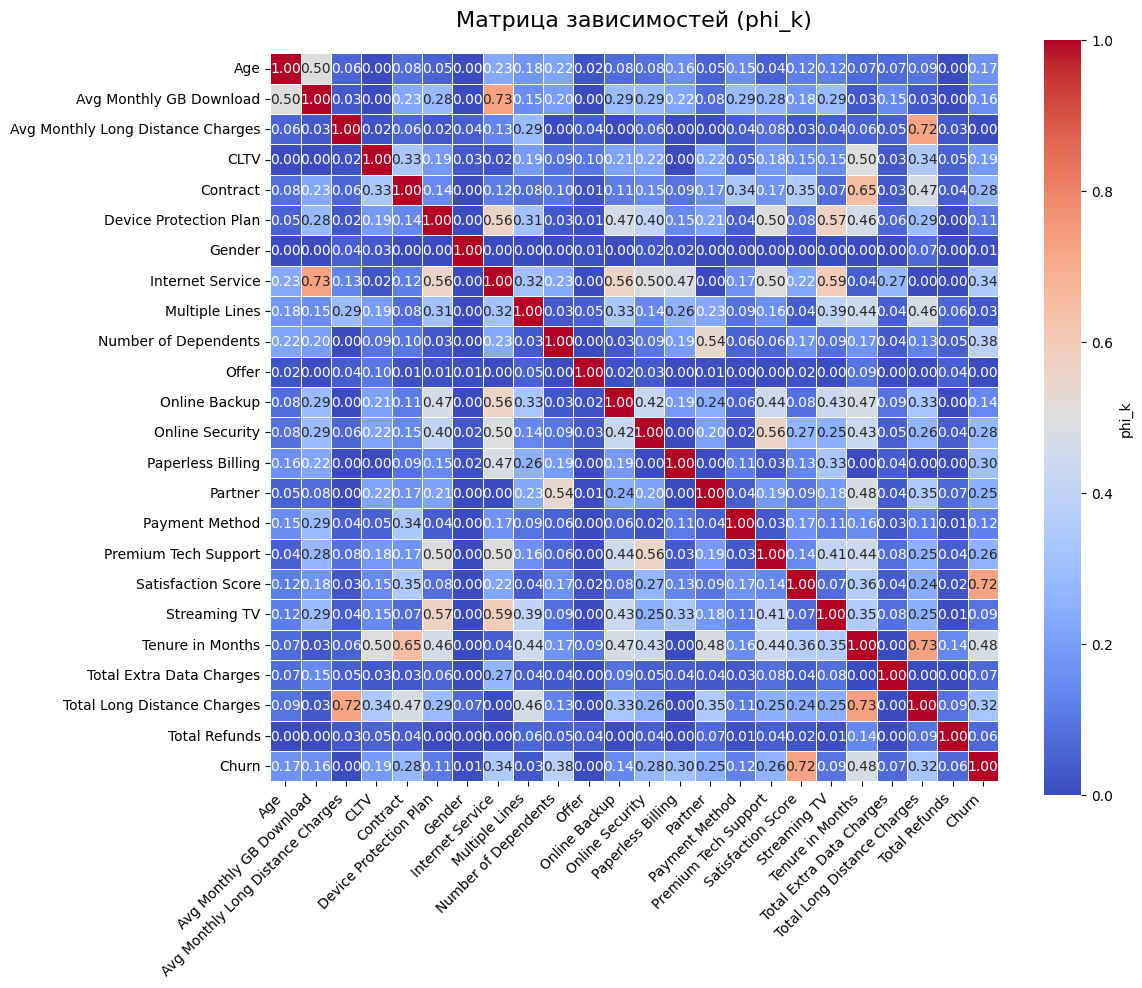

In [33]:
df_copy = df.copy()
df_copy['Churn'] = y
phik_matrix = df_copy.phik_matrix()

plot_phik(phik_matrix)

In [34]:
df.shape

(4225, 23)

Число признаков сократилось с 50 до 23.

### 3.3 Анализ целевой переменной

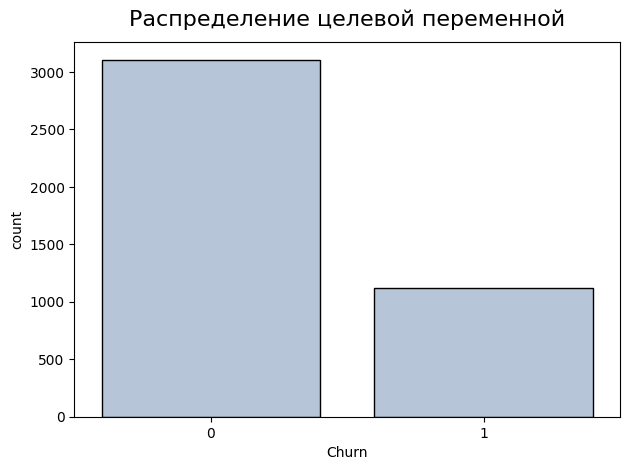

In [35]:
sns.countplot(x=y, color='lightsteelblue', edgecolor='black')
plt.title("Распределение целевой переменной", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Классы не сбалансировано, потребуется использовать инструменты для балансировки классов.

## 4. Загрузка (Load)

In [37]:
save_path = os.path.join('..', 'data', 'processed', 'eda_telco_customer_churn_train.csv')

df['Churn'] = y
df.to_csv(save_path, index=False)

## 5. Pipeline

Создадим Pipeline для преобразования признаков:

In [38]:
def drop_columns(X):
    X = X.copy()
    columns_to_drop = ['Churn Category', 'Churn Reason', 'Churn Score', 'Customer ID', 'Customer Status', 'Dependents', 'Under 30', 
                       'Senior Citizen', 'Lat Long', 'Latitude', 'Longitude', 'City', 'Population', 'Zip Code',
                       'Referred a Friend', 'Married', 'Number of Referrals',  'Unlimited Data', 'Internet Type', 'Phone Service', 
                       'Streaming Music', 'Streaming Movies', 'Total Revenue', 'Total Charges', 'Monthly Charge', 'Country', 'Quarter', 'State']
    columns_to_drop = [col for col in columns_to_drop if col in X.columns]
    if columns_to_drop:
        X = X.drop(columns_to_drop, axis=1)
    return X

def fill_na(X):
    X = X.copy() 
    object_columns = X.select_dtypes(include=['object', 'category']).columns
    for col in object_columns:
        X[col] = X[col].fillna('0')
    
    numeric_columns = X.select_dtypes(include=[np.number]).columns
    for col in numeric_columns:
        if X[col].isna().any():
            X[col] = X[col].fillna(X[col].mean())
    return X

def to_bin(X):
    X = X.copy()
    columns_to_bin = ['Offer', 'Number of Dependents', 'Total Extra Data Charges', 'Total Refunds']
    for col in columns_to_bin:
        if X[col].dtype == 'object' or X[col].dtype.name == 'category':
            X[col] = (X[col] != '0').astype(int)
        else:
            X[col] = (X[col] > 0).astype(int)
    return X



drop_transformer = FunctionTransformer(drop_columns)
fill_na_transformer = FunctionTransformer(fill_na)
to_bin_transformer = FunctionTransformer(to_bin)

pipeline_data = Pipeline([
    ('drop_columns', drop_transformer),
    ('log_transform', fill_na_transformer),
    ('create_features', to_bin_transformer),
])

Загрузка каждого датасета отдельно (тренировочный, валидационный, тестовый):

In [39]:
train = pd.read_csv("../data/raw/raw_eda_telco_customer_churn_train.csv")
val = pd.read_csv("../data/raw/raw_eda_telco_customer_churn_validation.csv")
test = pd.read_csv("../data/raw/raw_eda_telco_customer_churn_test.csv")

Применим pipeline ко всем данным:

In [40]:
X_train_processed = pipeline_data.fit_transform(train)  
X_val_processed = pipeline_data.transform(val)  
X_test_processed = pipeline_data.transform(test)

Сохраним новые датасеты:

In [41]:
save_path = os.path.join('..', 'data', 'processed')

X_train_processed.to_csv(os.path.join(save_path, 'eda_telco_customer_churn_train.csv'), index=False)

X_val_processed.to_csv(os.path.join(save_path, 'eda_telco_customer_churn_val.csv'), index=False)
X_test_processed.to_csv(os.path.join(save_path, 'eda_telco_customer_churn_test.csv'), index=False)

# Итог

1. Проанализирован датасет с 50 признаками и 1 целевой переменной. В результате удаления уникальных столбцов, коррелированных признаков и преобразования признаков в бинарный вид осталось 23 признака и 1 целевая переменная. 
2. Часть числовых признаков имеет скошенный вид, для обучения линейных моделей и моделей, которые чувствительны к расстояниям, потребуется привести их к логарифмическому масштабу.
3. Часть категориальных признаков, в том числе целевая переменная, имеют сильный дисбаланс.
4. На основе анализа был создан pipeline, которым необходимо применять для новых данных.